## Mock Brief: Maven Toys Sales & Profitability Analysis
From: Senior Data Analyst  
To: John Karounis (Junior/Mid-Level Analyst)  
We need a comprehensive analysis of Maven Toys' sales, profitability, and inventory performance across our 50 stores. The executive team is evaluating where to invest next — whether that's expanding into new cities, adjusting product mix, or optimizing inventory. Your analysis will inform those decisions.

**Part 1: Data Preparation & Validation**

- Merge all tables into an analysis-ready dataset
- Engineer key metrics: revenue, profit, margin per transaction
- Clean and validate (nulls, duplicates, data types, price columns with $ signs)
- Document any data quality issues or assumptions

**Part 2: Profitability Analysis**

- Which product categories and individual products drive the most profit (not just revenue)?
- Are high-revenue products actually high-margin? Where are the gaps?
- Break down profitability by store location type (Downtown, Commercial, Residential, Airport)
- Per-store profitability — are some stores underperforming given their location type?

**Part 3: Sales Patterns & Seasonality**

- Monthly/quarterly sales trends across the 21-month window
- Do all product categories follow the same seasonal pattern, or do some behave differently?
- Day-of-week effects — are weekends meaningfully different from weekdays?
- Identify any anomalies or unusual spikes/dips

**Part 4: Store Performance & Location Strategy**

- Compare store performance across location types, controlling for number of stores (per-store averages, not just totals)
- Do stores in multi-store cities perform differently than stores in single-store cities? (competition/cannibalization question)
- Does store age (years since opening) correlate with performance?
- Which cities are over/underperforming relative to their number of stores?

**Part 5: Inventory Efficiency**

- Calculate inventory turnover and days-of-supply per product per store
- Which products are chronically out of stock? Estimate potential lost revenue
- Which stores are sitting on excess inventory? Where is capital being wasted?
- Is there a mismatch between what sells fast and what's stocked heavily?

**Part 6: Statistical Validation & Executive Summary**

- Test whether profitability differs significantly across location types (ANOVA + effect size)
- Test whether product category sales mix varies by location type (chi-square)
- Test seasonal patterns statistically — not just "it looks higher in Q2" but is it significant?

Executive summary with findings and data-backed recommendations for the expansion decision

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy.stats import shapiro, levene, f_oneway, chi2_contingency
import warnings; warnings.filterwarnings('ignore')

In [2]:
# Download datasets 
sales = pd.read_csv('Maven Toys Data/sales.csv')
products = pd.read_csv('Maven Toys Data/products.csv')
inventory = pd.read_csv('Maven Toys Data/inventory.csv')
stores = pd.read_csv('Maven Toys Data/stores.csv')

data_dictionary = pd.read_csv('Maven Toys Data/data_dictionary.csv')
calendar = pd.read_csv('Maven Toys Data/calendar.csv')
# data_dictionary and calendar were reviewed for reference only 

# Take a basic look at the data

# print(sales.head())
# print(products.head())
# print(inventory.head())
# print(stores.head())
# print(data_dictionary.head())
# print(calendar.head())

# print(sales.info())
# print(products.info())
# print(inventory.info())
# print(stores.info())

In [3]:
# Clean the data 

# Convert Date from sales to Datetime
sales['Date'] = pd.to_datetime(sales['Date'])
print(sales.dtypes) # Converted successfully

# Strip the $ and whitespace from Product_Cost and Product_Price and convert to float
products['Product_Cost'] = products['Product_Cost'].str.replace('$', '', regex=False).str.strip().astype(float)
products['Product_Price'] = products['Product_Price'].str.replace('$', '', regex=False).str.strip().astype(float)

print(products.head())
print(products.dtypes) # Replacement and conversion successful

# Convert Store_Open_Date to datetime
stores['Store_Open_Date'] = pd.to_datetime(stores['Store_Open_Date'])
print(stores.dtypes) # Conversion successful

Sale_ID                int64
Date          datetime64[ns]
Store_ID               int64
Product_ID             int64
Units                  int64
dtype: object
   Product_ID      Product_Name Product_Category  Product_Cost  Product_Price
0           1     Action Figure             Toys          9.99          15.99
1           2    Animal Figures             Toys          9.99          12.99
2           3   Barrel O' Slime     Art & Crafts          1.99           3.99
3           4  Chutes & Ladders            Games          9.99          12.99
4           5  Classic Dominoes            Games          7.99           9.99
Product_ID            int64
Product_Name         object
Product_Category     object
Product_Cost        float64
Product_Price       float64
dtype: object
Store_ID                    int64
Store_Name                 object
Store_City                 object
Store_Location             object
Store_Open_Date    datetime64[ns]
dtype: object


## Part 1: Data Loading & Cleaning

Four datasets were loaded: sales (829,262 transactions), products (35 items), stores (50 locations), and inventory (1,593 product-store records). Data dictionary and calendar tables were loaded for reference but will not be used directly for analysis. Initial inspection revealed no null values across any table.  
Three data type corrections were needed: the Date column in sales and Store_Open_Date in stores were converted from object to datetime, and Product_Cost/Product_Price had dollar signs and trailing whitespace stripped before converting to float.

In [4]:
# Check for duplicate rows
print(sales.duplicated().sum())
print(stores.duplicated().sum())
print(products.duplicated().sum())
print(inventory.duplicated().sum())
# No duplicate rows in any DataFrame

0
0
0
0


In [5]:
# Check Product_ID, Store_ID & Sale_ID for unique values
print(stores['Store_ID'].nunique())
print(products['Product_ID'].nunique())
print(sales['Sale_ID'].unique())
# Store_ID has 50 unique values as expected
# Product_ID has 35 unique values as expected
# Sale_ID has 829262 unique values as expected

50
35


[     1      2      3 ... 829260 829261 829262]


In [6]:
# Filter for rows where Store_ID doesn't exist in stores
sales[~sales['Store_ID'].isin(stores['Store_ID'])] # All good

,Sale_ID,Date,Store_ID,Product_ID,Units


In [7]:
# Filter for rows where Product_ID doesn't exist in products
sales[~sales['Product_ID'].isin(products['Product_ID'])] # All good

,Sale_ID,Date,Store_ID,Product_ID,Units


In [8]:
# Check Units for 0 or negative values
print(sales[sales['Units'] <= 0]) # All good

# Check Product_Cost for 0 or negative values
print(products[products['Product_Cost'] <= 0]) # All good

# Check Product_Price for 0 or negative values
print(products[products['Product_Price'] <= 0]) # All good

Empty DataFrame
Columns: [Sale_ID, Date, Store_ID, Product_ID, Units]
Index: []
Empty DataFrame
Columns: [Product_ID, Product_Name, Product_Category, Product_Cost, Product_Price]
Index: []
Empty DataFrame
Columns: [Product_ID, Product_Name, Product_Category, Product_Cost, Product_Price]
Index: []


In [9]:
# Cross merge stores and products 
stores_products_cross = pd.merge(stores, products, how='cross')

# Merge the cross with inventory
stores_products_cross_inventory = pd.merge(stores_products_cross, inventory, how='left', indicator=True)

# Create a df of left only 
missing = stores_products_cross_inventory[stores_products_cross_inventory['_merge'] == 'left_only']
print(missing.shape)

# Check the value counts of Store_Name and Product_Name
#print(missing['Store_Name'].value_counts())
#print(missing['Product_Name'].value_counts())

# Filter sales for one of the missing products 
missing_sales = missing[['Store_ID', 'Product_ID']].merge(sales, on=['Store_ID', 'Product_ID'])
print(missing_sales)
# 6,232 transactions for store-product combos that don't exist in inventory

(157, 12)
      Store_ID  Product_ID  Sale_ID       Date  Units
0            2          16   143683 2022-05-16      1
1            2          16   143687 2022-05-16      1
2            2          16   143908 2022-05-16      1
3            2          16   161143 2022-05-31      1
4            2          16   161174 2022-05-31      1
...        ...         ...      ...        ...    ...
6227        47          20   325150 2022-10-25      1
6228        47          20   325387 2022-10-25      1
6229        47          20   325391 2022-10-25      1
6230        47          20   325426 2022-10-25      1
6231        47          20   325697 2022-10-25      1

[6232 rows x 5 columns]


## Part 1: Data Validation

No duplicate rows were found in any of the four tables. Sale_ID was confirmed unique across all 829,262 transactions, Store_ID has 50 unique values, and Product_ID has 35 - all as expected.  

Referential integrity was verified by checking that every Store_ID and Product_ID in the sales table exists in the stores and products tables respectively. No orphan records were found.  

Units, Product_Cost, and Product_Price were checked for zero or negative values - none were found.  

The inventory table contains 1,593 records out of an expected 1,750 (50 stores x 35 products), leaving 157 store-product combinations unaccounted for.  
A cross merge identified the gaps: six products - Chutes & Ladders, Monopoly, Mini Basketball Hoop, Uno Card Game, Classic Dominoes, and Jenga - are each missing from approximately 25 stores. However, merging these missing combinations against sales returned 6,232 transactions, confirming these stores do sell these products.  
The inventory table is a point-in-time snapshot and is incomplete - this limitation will be accounted for in the inventory efficiency analysis. 

In [10]:
# Merge DataFrames
sales_products = pd.merge(sales, products, on='Product_ID', how='inner')
sales_products_stores = pd.merge(sales_products, stores, on='Store_ID', how='inner')

# Feature Engineering
# Calculate Revenue, Cost, and Profit
sales_products_stores['Revenue'] = sales_products_stores['Units'] * sales_products_stores['Product_Price']
sales_products_stores['Cost'] = sales_products_stores['Units'] * sales_products_stores['Product_Cost']
sales_products_stores['Profit'] = sales_products_stores['Revenue'] - sales_products_stores['Cost']
sales_products_stores['Profit_Margin'] = round((sales_products_stores['Profit'] / sales_products_stores['Revenue']) * 100, 2)

# Add Month, Year, Quarter, and Day of Week
sales_products_stores['Year'] = sales_products_stores['Date'].dt.year
sales_products_stores['Month'] = sales_products_stores['Date'].dt.month
sales_products_stores['Quarter'] = sales_products_stores['Date'].dt.quarter
sales_products_stores['Day_of_Week'] = sales_products_stores['Date'].dt.day_of_week
print(sales_products_stores.info())
print(sales_products_stores.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sale_ID           829262 non-null  int64         
 1   Date              829262 non-null  datetime64[ns]
 2   Store_ID          829262 non-null  int64         
 3   Product_ID        829262 non-null  int64         
 4   Units             829262 non-null  int64         
 5   Product_Name      829262 non-null  object        
 6   Product_Category  829262 non-null  object        
 7   Product_Cost      829262 non-null  float64       
 8   Product_Price     829262 non-null  float64       
 9   Store_Name        829262 non-null  object        
 10  Store_City        829262 non-null  object        
 11  Store_Location    829262 non-null  object        
 12  Store_Open_Date   829262 non-null  datetime64[ns]
 13  Revenue           829262 non-null  float64       
 14  Cost

## Part 1: Data Merging and Feature Engineering

Sales was merged with products on Product_ID and then with stores on Store_ID using inner joins, producing a unified DataFrame of 829,262 rows and 21 columns with no data loss.  
Three financial metrics were calculated per transaction: Revenue (Units x Product_Price), Cost (Units x Product_Cost), and Profit (Revenue-Cost). Profit margin was added as a percentage (Profit / Revenue * 100, rounded to 2 decimal places).  
Time features were extracted from the Date column: Year, Month, Quarter, and Day of Week to support seasonality and trend analysis.

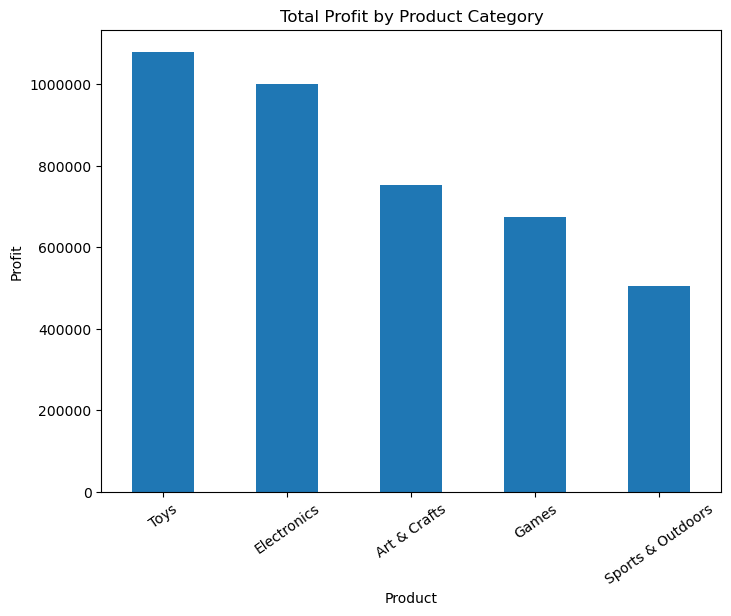

<Figure size 640x480 with 0 Axes>

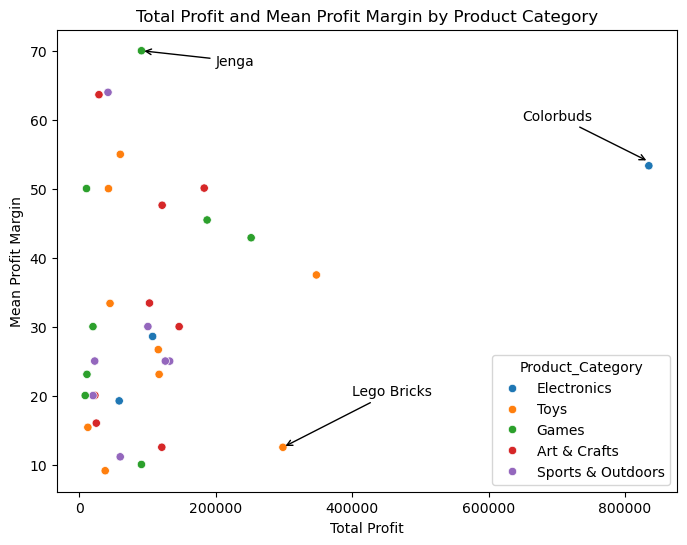

<Figure size 640x480 with 0 Axes>

In [11]:
# Profitability by product category

profit_by_product_category = sales_products_stores.groupby('Product_Category')[['Revenue', 'Cost', 'Profit']].sum().sort_values(by='Profit', ascending=False)
#print(f'The revenue, cost, and profit by Product_Category are:\n {profit_by_product_category}\n')

mean_margin_by_category = sales_products_stores.groupby('Product_Category')['Profit_Margin'].mean().sort_values(ascending=False).round(2)
#print(f'The mean profit margin by Product_Category is:\n {mean_margin_by_category}')

# Check Total Profit and Mean Profit Margin by Product_Category and Product_Name
profit_margin_by_category_name = sales_products_stores.groupby(['Product_Category', 'Product_Name'])[['Profit', 'Profit_Margin']].agg({'Profit': 'sum', 'Profit_Margin': 'mean'}).sort_values(by='Profit', ascending=False)
#print(f'The total profit and mean margin by Product_Category and Product_Name are:\n {profit_margin_by_category_name}')

# Create bar chart of total Profit by Product_Category
sales_products_stores.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(8,6))
plt.title('Total Profit by Product Category')
plt.xlabel('Product')
plt.ylabel('Profit')
plt.xticks(rotation=35)
plt.ticklabel_format(style='plain', axis='y')
plt.show()
plt.clf()

# Create scatter plot of profit_margin_by_category_name
plt.figure(figsize=(8, 6))
sns.scatterplot(data=profit_margin_by_category_name, x='Profit', y='Profit_Margin', hue='Product_Category')
plt.title('Total Profit and Mean Profit Margin by Product Category')
plt.xlabel('Total Profit')
plt.ylabel('Mean Profit Margin')
plt.annotate('Colorbuds', xy=(834944, 53.97), xytext=(650000, 60), arrowprops=dict(arrowstyle='->'), color='black')
plt.annotate('Lego Bricks', xy=(298685, 12.50), xytext=(400000, 20), arrowprops=dict(arrowstyle='->'), color='black')
plt.annotate('Jenga', xy=(91378, 70.07), xytext=(200000, 68), arrowprops=dict(arrowstyle='->'), color='black')
plt.show()
plt.clf()

The total Profit, Revenue, and mean Profit_Margin by store location are:
                    Revenue     Profit  Profit_Margin
Store_Location                                      
Downtown        8219596.27  2248728.0          30.94
Commercial      3279139.52   926864.0          31.59
Residential     1656113.98   460388.0          31.50
Airport         1289722.58   378049.0          31.87

The Revenue and Profit per store are:
                   Revenue     Profit
Store_Location                      
Downtown        283434.35   77542.34
Commercial      273261.63   77238.67
Residential     276019.00   76731.33
Airport         429907.53  126016.33



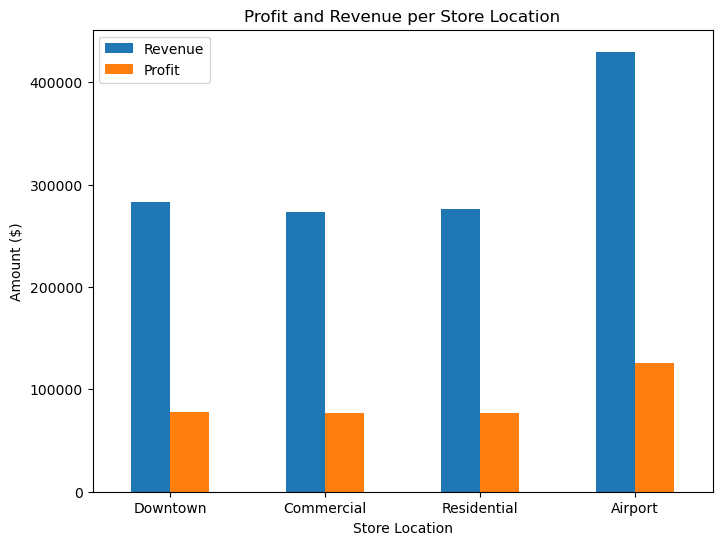

<Figure size 640x480 with 0 Axes>

In [12]:
# Profitability by store location

# Calculate total Profit, Revenue, and mean Profit_Margin per location store
revenue_profit_margin_by_location = sales_products_stores.groupby('Store_Location')[['Revenue', 'Profit', 'Profit_Margin']].agg({'Revenue': 'sum', 'Profit': 'sum', 'Profit_Margin': 'mean'}).sort_values(by='Profit', ascending=False)
print(f'The total Profit, Revenue, and mean Profit_Margin by store location are:\n {revenue_profit_margin_by_location.round(2)}\n')

revenue_profit_per_store = revenue_profit_margin_by_location[['Revenue', 'Profit']].div(stores['Store_Location'].value_counts(), axis=0)
print(f'The Revenue and Profit per store are:\n {revenue_profit_per_store.round(2)}\n')

# Create a grouped bar chart of revenue_profit_per_store
revenue_profit_per_store.plot(kind='bar', figsize=(8,6))
plt.title('Profit and Revenue per Store Location')
plt.xlabel('Store Location')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()
plt.clf()

## Part 2: Profitability Analysis

Profitability was examined at the category, product, and store location levels.  

Toys generated the highest total profit ($1.08M) driven by volume, but Electronics was the most efficient category with the highest mean profit margin (45.86%) compared to Toys at just 25.05%.  
Sports & Outdoors had both the lowest total profit ($506K) and the lowest margin (22.08%).  

At the product level, Colorbuds (Electronics) was the standout performer - the single highest-profit product at $835K with a 53% margin.  
Lego Bricks ranked 3rd in total profit ($299K) but operated on a slim 12.5% margin, making it a high-revenue volume play with low efficiency.  
Jenga had the highest margin of any product at 70% but generated only $91K in total profit, representing an underexplored opportunity.  

Profitability by store location type revealed that margins are nearly identical across all four types (30.9%-31.9%), indicating consistent pricing and product mix.  
However, per-store analysis told a different story; Airport stores averaged $126K profit per store - significantly higher than Downtown ($77K), Commercial ($77K), and Residential ($77K), which were virtually equal.  
Airport locations generate roughly 63% more profit per store despite representing only 3 of 50 locations.

The Revenue and Profit by Month are:
               Revenue    Profit
Month Year                     
1     2022  542554.91  167126.0
      2023  747196.22  205074.0
2     2022  541351.65  161861.0
      2023  722632.19  189314.0
3     2022  589485.19  173992.0
      2023  883515.64  231909.0
4     2022  681072.98  190099.0
      2023  827691.07  215096.0
5     2022  672369.90  186894.0
      2023  825319.49  210347.0
6     2022  661980.22  189815.0
      2023  808299.25  207212.0
7     2022  556034.23  176922.0
      2023  828348.86  209807.0
8     2022  489422.73  158931.0
      2023  660877.07  175038.0
9     2022  585844.04  166397.0
      2023  658194.48  180445.0
10    2022  623874.39  178799.0
11    2022  661304.15  192873.0
12    2022  877203.69  246078.0


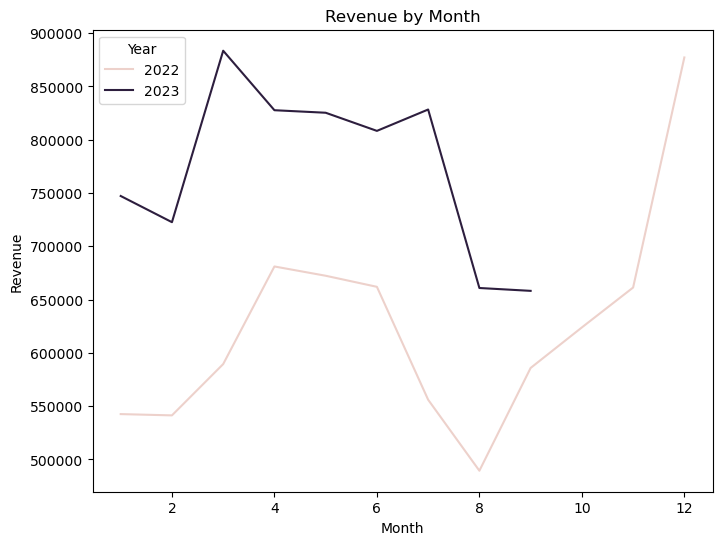

<Figure size 640x480 with 0 Axes>

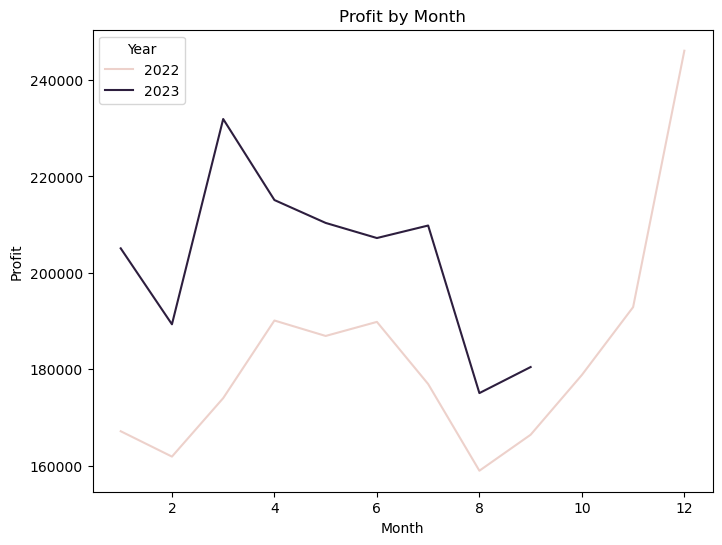

<Figure size 640x480 with 0 Axes>

In [13]:
# Revenue and Profit by Month
revenue_profit_by_month = sales_products_stores.groupby(['Month', 'Year'])[['Revenue', 'Profit']].sum()
print(f'The Revenue and Profit by Month are:\n {revenue_profit_by_month}')

# Create line chart of Revenue by Month
plt.figure(figsize=(8,6))
sns.lineplot(data=revenue_profit_by_month, x='Month', y='Revenue', hue='Year')
plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()
plt.clf()

# Create a line chart of Profit by Month
plt.figure(figsize=(8,6))
sns.lineplot(data=revenue_profit_by_month, x='Month', y='Profit', hue='Year')
plt.title('Profit by Month')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.show()
plt.clf()

The Revenue by Product_Category and Month is:
 Month  Product_Category 
1      Art & Crafts          35097.18
       Electronics          143088.62
       Games                 97575.98
       Sports & Outdoors     74945.88
       Toys                 191847.25
Name: Revenue, dtype: float64



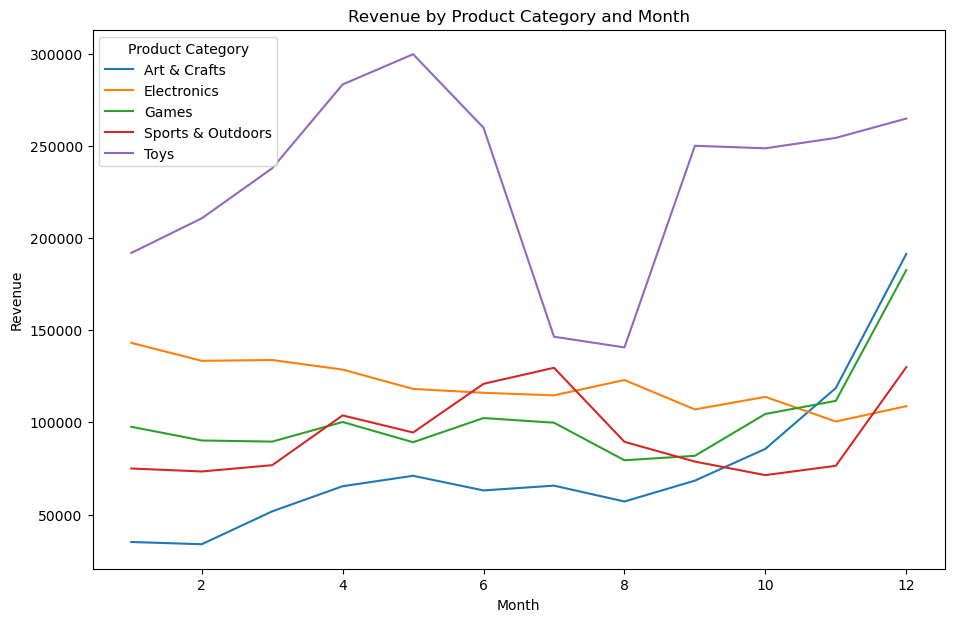

<Figure size 640x480 with 0 Axes>

In [14]:
# Revenue by Product_Category and Month
revenue_by_category_month = sales_products_stores[sales_products_stores['Year'] == 2022].groupby(['Month', 'Product_Category'])['Revenue'].sum()

print(f'The Revenue by Product_Category and Month is:\n {revenue_by_category_month.head()}\n')

# Create a line chart of revenue_by_category_month
plt.figure(figsize=(11,7))
sns.lineplot(data=revenue_by_category_month.reset_index(), x='Month', y='Revenue', hue='Product_Category')
plt.title('Revenue by Product Category and Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend(title='Product Category')
plt.show()
plt.clf()

The Revenue by Day_of_Week is:
 Day_of_Week
0     783415.18
1     882038.80
2     921102.23
3    1122262.58
4    1397686.31
5    1465395.47
6     910597.51
Name: Revenue, dtype: float64


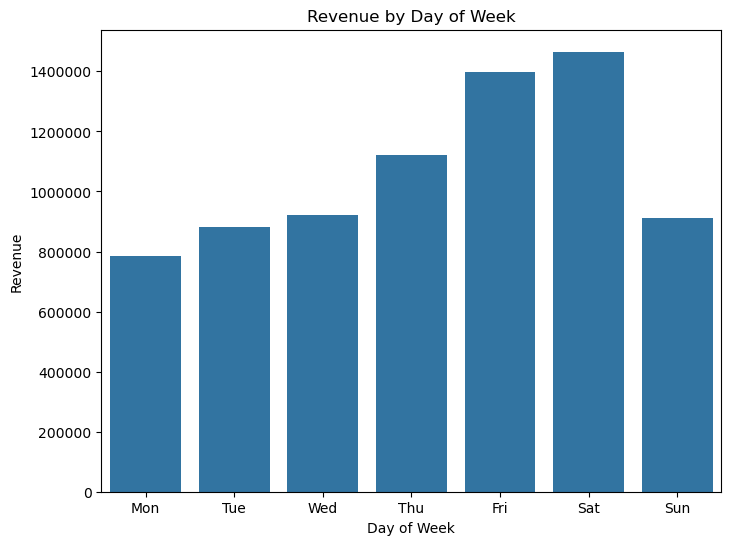

<Figure size 640x480 with 0 Axes>

In [15]:
# Revenue by Day of Week
revenue_by_dow = sales_products_stores[sales_products_stores['Year'] == 2022].groupby('Day_of_Week')['Revenue'].sum()
print(f'The Revenue by Day_of_Week is:\n {revenue_by_dow}')

# Create a barplot of revenue_by_dow
day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
plt.figure(figsize=(8,6))
sns.barplot(x=revenue_by_dow.index.map(day_names), y=revenue_by_dow.values)
plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
plt.show()
plt.clf()

The revenue by Quarter is:
 Quarter
1    1673391.75
2    2015423.10
3    1631301.00
4    2162382.23
Name: Revenue, dtype: float64



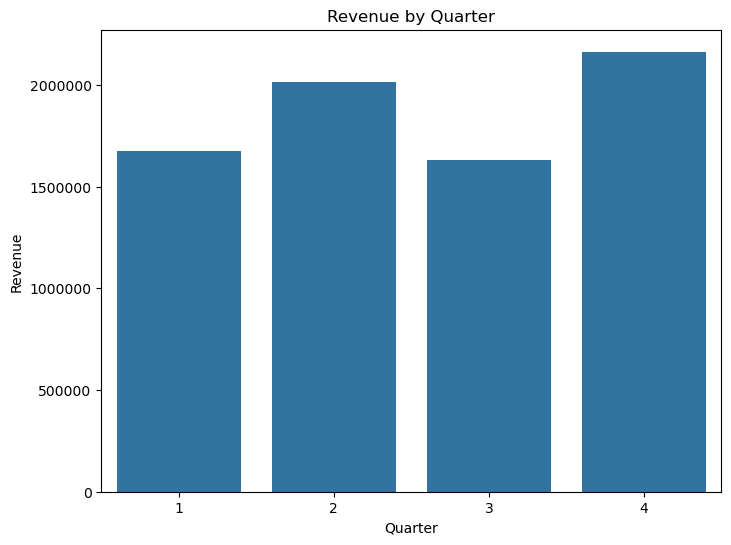

<Figure size 640x480 with 0 Axes>

In [16]:
# Revenue by Quarter
revenue_by_quarter = sales_products_stores[sales_products_stores['Year'] == 2022].groupby('Quarter')['Revenue'].sum()
print(f'The revenue by Quarter is:\n {revenue_by_quarter}\n')

# Create a barplot of revenue_by_quarter
plt.figure(figsize=(8,6))
sns.barplot(x=revenue_by_quarter.index, y=revenue_by_quarter.values)
plt.title('Revenue by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
plt.show()
plt.clf()

## Part 3: Sales Patterns & Seasonality

Monthly revenue trends showed consistent year-over-year growth, with 2023 outperforming 2022 in every comparable month. Revenue follows a seasonal pattern: a peak in spring (March-April), a summer decline through August, and a strong recovery into December driven by the holiday season.  

Category-level seasonality revealed that not all categories follow the same pattern.  
Toys showed the most pronounced seasonality, peaking in April then declining sharply through summer, while Art & Crafts climbed steadily with a December spike.  
Electronics remained relatively flat throughout the year, making it the most seasonally stable category.

Quarterly analysis confirmed this: Q2 ($2.01M) and Q4 ($2.16M) were the strongest quarters in 2022, while Q3 ($1.63M) was the weakest - driven largely by the Toys category summer decline. 

Day-of-week analysis showed a clear ramp from Monday ($783K) to Saturday ($1.47M), with Saturday generating nearly double Monday's revenue. Sunday drops back to midweek levels ($911K).  
This suggests weekend foot traffic is a major revenue driver, particularly Friday and Saturday.

In [17]:
# Profit by Store_Name and Store_Location
profit_by_name_location = sales_products_stores.groupby(['Store_Name', 'Store_Location'])['Profit'].sum().sort_values(ascending=False)
#print(f'The profit by Store_Name and Store_Location is: {profit_by_name_location}')

# Calculate stores per city
stores_per_city_count = stores.groupby('Store_City')['Store_ID'].count()
#print(f'The store per city count is:\n {stores_per_city_count}')

# Calculate profit per city
total_profit_per_city = sales_products_stores.groupby('Store_City')['Profit'].sum().sort_values(ascending=False)
#print(f'The total profit per city is:\n {total_profit_per_city}')

# Calculate per store profit
per_store_profit = total_profit_per_city / stores_per_city_count

city_analysis = pd.DataFrame({
    'Store_Count': stores_per_city_count,
    'Total_Profit': total_profit_per_city,
    'Profit_Per_Store': per_store_profit
})

# Add a City_Type column depending on Store_Count 
city_analysis['City_Type'] = city_analysis['Store_Count'].apply(lambda x: 'Multi' if x > 1 else 'Single')

print(f"The mean Profit_Per_Store by City_Type is:\n {city_analysis.groupby('City_Type')['Profit_Per_Store'].mean().round(2)}")

The mean Profit_Per_Store by City_Type is:
 City_Type
Multi     84754.15
Single    67443.41
Name: Profit_Per_Store, dtype: float64


In [18]:
print(city_analysis.sort_values(by='Profit_Per_Store', ascending=False))

                  Store_Count  Total_Profit  Profit_Per_Store City_Type
Store_City                                                             
Cuidad de Mexico            4      465558.0     116389.500000     Multi
Guadalajara                 4      368930.0      92232.500000     Multi
Morelia                     1       90484.0      90484.000000    Single
Hermosillo                  3      263608.0      87869.333333     Multi
Mexicali                    2      175048.0      87524.000000     Multi
Monterrey                   4      346729.0      86682.250000     Multi
Ciudad Victoria             1       83088.0      83088.000000    Single
Xalapa                      2      163720.0      81860.000000     Multi
Saltillo                    2      163248.0      81624.000000     Multi
Toluca                      2      162702.0      81351.000000     Multi
Guanajuato                  3      235047.0      78349.000000     Multi
Puebla                      3      229694.0      76564.666667   

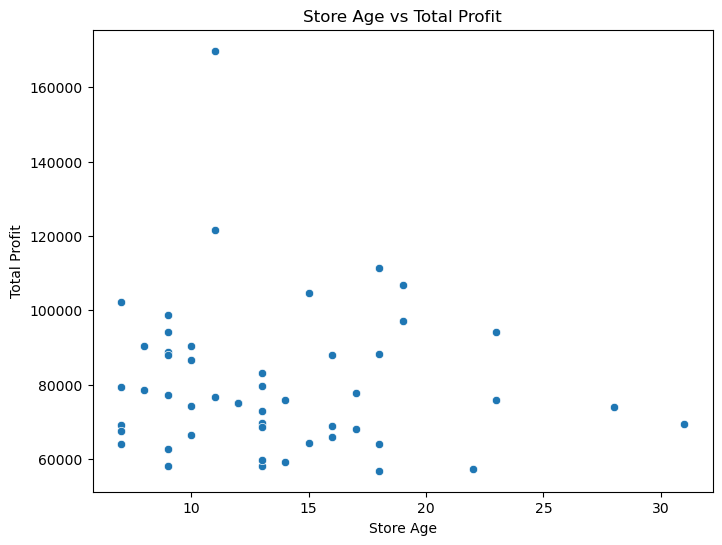

-0.08439237774128117


<Figure size 640x480 with 0 Axes>

In [19]:
# Calculate each store's age
store_age = ((pd.Timestamp('2023-09-30') - stores['Store_Open_Date']) / pd.Timedelta(days=365)).astype(int)
#print(f"Each store's age:\n {store_age}")

# Calculate total profit per store
total_profit_per_store = sales_products_stores.groupby('Store_ID')['Profit'].sum().sort_values(ascending=False)
#print(f'The total profit per store is:\n {total_profit_per_store}')

store_analysis = stores[['Store_ID', 'Store_Name']].copy()
store_analysis['Store_Age'] = store_age.values
store_analysis['Total_Profit'] = store_analysis['Store_ID'].map(total_profit_per_store)

# Create scatter plot of Store_Age vs Total_Profit
plt.figure(figsize=(8,6))
sns.scatterplot(data=store_analysis, x='Store_Age', y='Total_Profit')
plt.title('Store Age vs Total Profit')
plt.xlabel('Store Age')
plt.ylabel('Total Profit')
plt.show()
plt.clf()

# Correlate Store_Age with Total_Profit
print(store_analysis['Store_Age'].corr(store_analysis['Total_Profit']))

## Part 4: Store Performance & Location Strategy

Individual store performance varied significantly, ranging from $57K (Cuernavaca 1) to $170K (Ciudad de Mexico 2).  
The two top performers were Airport stores, though the third Airport store (Monterrey 3) ranked mid-pack at $87K - suggesting the Airport average is skewed by one outlier rather than reflecting consistent location-type superiority.

A cannibalization analysis compared per-store profit in multi-store cities vs single-store cities.  
Multi-store cities averaged $84.8K profit per store compared to $67.4K for single-store cities, indicating no evidence of cannibalization.  
Cities with multiple stores appear to be larger, higher-demand markets rather than oversaturated ones, supporting further expansion into existing multi-store cities.  

At the city-level, Ciudad de Mexico led with $116K profit per store, followed by Guadalajara ($92K) and Morelia ($90K).  
Cuernavaca ($57K) and La Paz ($57K) were the weakest performers. The six highest-performing cities per store were all multi-store markets, further reinforcing that additional locations do not dilute performance.  

Store age (ranging from 7 to 31 years) showed no meaningful correlation with total profit (r = -0.08).  
Performance appears to be driven by location and market characteristics rather than store maturity, which suggests new stores can reach full productivity quickly.


The total lost revenue for unstocked product is approximately: 17157.45



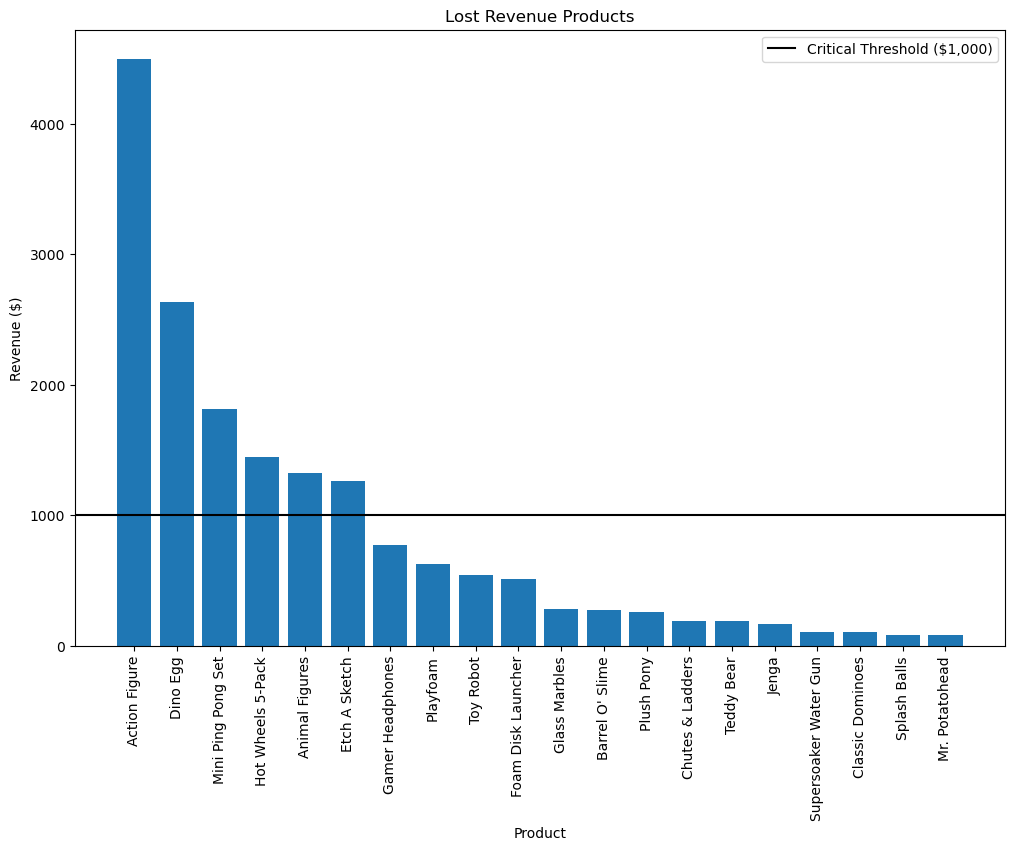

In [20]:
# Calculate the total days of the data
total_days = (sales_products_stores['Date'].max() - sales_products_stores['Date'].min()).days

# Calculate the mean sales per product per store
mean_sales_per_product_store = sales_products_stores.groupby(['Product_ID', 'Store_ID'])['Units'].sum()
mean_sales_per_product_store = mean_sales_per_product_store / total_days
mean_sales_per_product_store = mean_sales_per_product_store.rename('Daily_Sales_Rate')
#print(f'The mean sales per product per store are:\n {mean_sales_per_product_store}')

# Merge mean_sales_per_product_store with the inventory df
inventory_analysis = pd.merge(mean_sales_per_product_store, inventory, on=['Store_ID', 'Product_ID'])
#print(inventory_analysis)

# Calculate the days of supply for each product
days_of_supply = inventory_analysis['Stock_On_Hand'] / inventory_analysis['Daily_Sales_Rate']
#print(f'The days of supply for each product are:\n {days_of_supply.astype(int)}')

# Add days_of_supply in inventory_analysis
inventory_analysis['Days_of_Supply'] = days_of_supply
inventory_analysis['Days_of_Supply'] = inventory_analysis['Days_of_Supply'].astype(int)

# Filter for stock_at_hand = 0 
out_of_stock = inventory_analysis[inventory_analysis['Stock_On_Hand'] == 0]['Product_ID'].value_counts()
#print(f'The out of stock products are:\n {out_of_stock}')

# Merge out_of_stock with products to see names as well 
out_of_stock_names = pd.merge(out_of_stock, products, on='Product_ID')
#print(out_of_stock_names)

# Estimate lost revenue
# Merge inventory_analysis with products to get the name of each product
inventory_analysis = pd.merge(inventory_analysis, products, on='Product_ID')
stockout_analysis = inventory_analysis[inventory_analysis['Stock_On_Hand'] == 0].copy()

# Create Lost_Revenue_Day and Lost_Revenue_Month columns
stockout_analysis['Lost_Revenue_Day'] = stockout_analysis['Daily_Sales_Rate'] * stockout_analysis['Product_Price']
stockout_analysis['Lost_Revenue_Month'] = stockout_analysis['Lost_Revenue_Day'] * 30

lost_revenue = stockout_analysis.groupby('Product_Name')['Lost_Revenue_Month'].sum().sort_values(ascending=False)
#print(lost_revenue)
print(f'\nThe total lost revenue for unstocked product is approximately: {lost_revenue.sum().round(2)}\n')

# Create a bar chart of the lost revenue products
plt.figure(figsize=(12,8))
plt.bar(lost_revenue.index, lost_revenue.values)
plt.title('Lost Revenue Products')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=90)
plt.axhline(y=1000, color='black', label='Critical Threshold ($1,000)')
plt.legend()
plt.show()

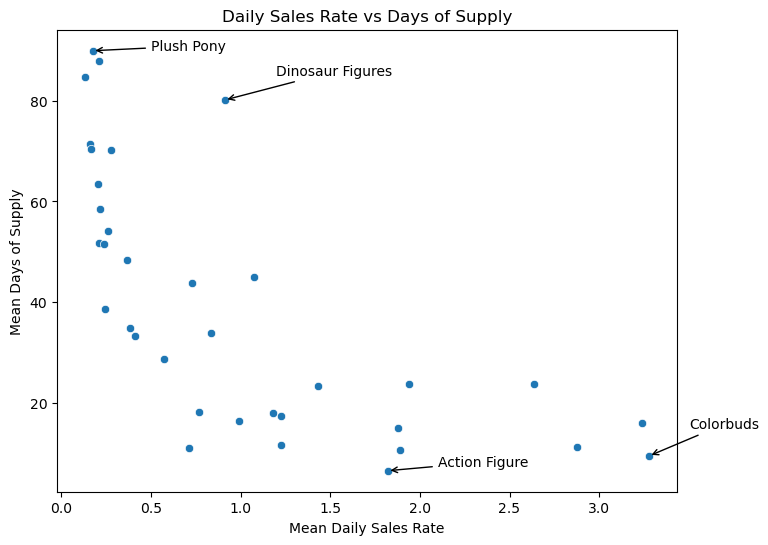

<Figure size 640x480 with 0 Axes>

In [21]:
# Look which product-store combos have high Days_of_Supply
sorted_by_days_of_supply = inventory_analysis.sort_values(by='Days_of_Supply', ascending=False)
#print(f'Products by Days_of_Supply:\n {sorted_by_days_of_supply.head(20)}')

mean_days_of_supply_by_product = inventory_analysis.groupby('Product_Name')['Days_of_Supply'].mean().sort_values(ascending=False)
#print(mean_days_of_supply_by_product)

mean_sales_rate_days_of_supply_by_product = inventory_analysis.groupby('Product_Name')[['Daily_Sales_Rate', 'Days_of_Supply']].mean().sort_values(by='Days_of_Supply', ascending=False)
#print(mean_sales_rate_days_of_supply_by_product)

# Create scatter plot of Daily_Sales_Rate by Days_of_Supply 
plt.figure(figsize=(8,6))
sns.scatterplot(data=mean_sales_rate_days_of_supply_by_product, x='Daily_Sales_Rate', y='Days_of_Supply')
plt.title('Daily Sales Rate vs Days of Supply')
plt.xlabel('Mean Daily Sales Rate')
plt.ylabel('Mean Days of Supply')
plt.annotate('Plush Pony', xy=(0.174222, 89.877551), xytext=(0.5, 90), arrowprops=dict(arrowstyle='->'))
plt.annotate('Action Figure', xy=(1.819717, 6.6), xytext=(2.1, 7.5), arrowprops=dict(arrowstyle='->'))
plt.annotate('Colorbuds', xy=(3.276860, 9.52), xytext=(3.5, 15), arrowprops=dict(arrowstyle='->'))
plt.annotate('Dinosaur Figures', xy=(0.910895, 80.1), xytext=(1.2, 85), arrowprops=dict(arrowstyle='->'))
plt.show()
plt.clf()

In [22]:
# Do a store-level view
# Calculate total Stock_On_Hand and mean Days_of_Supply by Store_ID
store_level_analysis = inventory_analysis.groupby('Store_ID')[['Stock_On_Hand', 'Days_of_Supply']].agg({'Stock_On_Hand': 'sum', 'Days_of_Supply': 'mean'}).sort_values(by='Days_of_Supply', ascending=False)
#print(store_level_analysis)

# Merge store_level_analysis with stores 
store_level_analysis_stores = pd.merge(store_level_analysis, stores, on='Store_ID')
#print(store_level_analysis_stores.head(10))

## Part 5: Inventory Efficiency

Inventory turnover was assessed by calculating the daily sales rate for each product-store combination (total units sold divided by the 638-day observation window) and merging this with the inventory snapshot.  
Days of supply was derived as stock on hand divided by daily sales rate, representing how long current inventory would last at the current pace of sales.  
This analysis was limited to the 1,593 store-product combinations present in the inventory table, as 157 combinations were identified as missing during validation.  

Of the 1,593 combinations, 77 had zero stock on hand at the time of the snapshot.  
Playfoam was out of stock at 13 stores and Hot Wheels 5-pack at 12, making them the most widespread stockouts. However, the products costing the company the most in estimated lost revenue told a different story.  
By multiplying each stockout's daily sales rate by its product price and projecting over a 30-day window, Action Figure emerged as the most costly stockout at approximately $4,497 per month, followed by Dino Egg ($2,631) and Mini Ping Pong Set ($1,817).  
Total estimated lost revenue across all stockouts was approximately $17,157 per month, with six products exceeding the $1,000 threshold accounting for the bulk of the impact.  

On the opposite end, several products showed signs of significant overstocking. Plush Pony averaged 90 days of supply across stores, followed by PlayDoh Playset (88 days) and Playfoam (85 days).  
The contrast with the understocked products was stark - Action Figure, the top lost revenue product, had only 6.6 days of supply on average, and Colorbuds, the company's most profitable product, held just 9.5 days.  
Dinosaur Figures stood out as an unusual case: despite a moderate daily sales rate of 0.91 units, it carried 80 days of supply, suggesting a stocking allocation problem rather than a demand issue.  

At the store level, mean days of supply ranged from approximately 80 days (Store 6, Mexicali) to 17 days (Store 28), with no clear pattern by location type or city.  
Two Hermosillo stores both appeared in the top 10 for excess inventory, possibly indicating a regional demand issue.  
The wide variation suggests inventory allocation is inconsistent across the chain, with some stores tying up capital in months of slow-moving stock while others operate lean.

In [23]:
# Grab the profit for each location
downtown_profit = sales_products_stores[sales_products_stores['Store_Location'] == 'Downtown']['Profit']
commercial_profit = sales_products_stores[sales_products_stores['Store_Location'] == 'Commercial']['Profit']
residential_profit = sales_products_stores[sales_products_stores['Store_Location'] == 'Residential']['Profit']
airport_profit = sales_products_stores[sales_products_stores['Store_Location'] == 'Airport']['Profit']

# Run Shapiro-Wilk test for the 4 variables
print('Null Hypothesis (Shapiro): The data is normally distributed')
print('Alternative Hypothesis (Shapiro): The data is not normally distributed\n')
a = 0.05

stat1, p1 = shapiro(downtown_profit)
stat2, p2 = shapiro(commercial_profit)
stat3, p3 = shapiro(residential_profit)
stat4, p4 = shapiro(airport_profit)

print(f'Stat1: {stat1.round(4)}, Pval1: {p1.round(4)}')
print(f'Stat2: {stat2.round(4)}, Pval2: {p2.round(4)}')
print(f'Stat3: {stat3.round(4)}, Pval3: {p3.round(4)}')
print(f'Stat4: {stat4.round(4)}, Pval4: {p4.round(4)}\n')

if p1 < a or p2 < a or p3 < a or p4 < a:
    print('Reject the Null Hypothesis (Shapiro)\n')
else:
    print('Fail to reject the Null Hypothesis (Shapiro)\n')

print('Normality violated, but with 800K+ transactions the CLT ensures the sampling distribution of means is approximately normal.')
print('ANOVA is robust to this violation at large sample sizes. Proceeding with ANOVA rather than Kruskal-Wallis.\n')

# Run Levene's test
print("Null Hypothesis (Levene's): All groups have equal variances")
print("Alternative Hypothesis (Levene's): At least one group's variance differs\n")

levene_stat, levene_pval = levene(downtown_profit, commercial_profit, residential_profit, airport_profit)
print(f"Levene's stat: {levene_stat}")
print(f"Levene's pval: {levene_pval}\n")

if levene_pval < a:
    print('Reject the Null Hypothesis (Levene)\n')
else:
    print('Fail to reject the Null Hypothesis (Levene)\n')

print('Equal variances violated. Unlike normality, unequal variances can bias the F-test, especially with unequal group sizes (Downtown: 29 stores vs Airport: 3)')
print("Using Welch's ANOVA, which does not assume equal variance.\n")

# Run Welch's ANOVA with pg
print('Null Hypothesis (ANOVA): There is no significant difference in profit between store locations')
print('Alternative Hypothesis (ANOVA): There is significant difference in profit between store locations\n')

result = pg.welch_anova(data=sales_products_stores, dv='Profit', between='Store_Location')
print(f'\n{result}\n')
print(f"F-stat: {result['F'][0]}")
print(f"Pval: {result['p-unc'][0]}\n")

if result['p-unc'][0] < a:
    print('Reject the Null Hypothesis (ANOVA)')
else:
    print('Fail to reject the Null Hypothesis (ANOVA)')

# Check effect size
eta_sq = result['np2'][0]
if eta_sq < 0.06:
    print('Effect Size: Small\n')
elif eta_sq < 0.14:
    print('Effect Size: Medium\n')
else:
    print('Effect Size: Large\n')

# Run Games-Howell post-hoc
posthoc = pg.pairwise_gameshowell(data=sales_products_stores, dv='Profit', between='Store_Location')
print(f'{posthoc}\n')

print("Welch's ANOVA is significant (F=647.39, p<0.001), but the effect size is negligible (η²=0.003). Store location type explains only 0.3% of the variance in profit.")
print("While the difference between locations is statistically real, it is not practically meaningful — product mix and individual store management likely matter far more than location type alone.")
print("Games-Howell post-hoc confirmed all pairwise comparisons are significant (p<0.001), but effect sizes are uniformly small (Hedges' g ranging from 0.03 to 0.19).")
print("Airport stores show the largest mean profit per transaction ($5.52), but even the largest pairwise difference (Airport vs Downtown, g=0.19) is practically modest.")

Null Hypothesis (Shapiro): The data is normally distributed
Alternative Hypothesis (Shapiro): The data is not normally distributed

Stat1: 0.6846, Pval1: 0.0
Stat2: 0.7067, Pval2: 0.0
Stat3: 0.7027, Pval3: 0.0
Stat4: 0.6803, Pval4: 0.0

Reject the Null Hypothesis (Shapiro)

Normality violated, but with 800K+ transactions the CLT ensures the sampling distribution of means is approximately normal.
ANOVA is robust to this violation at large sample sizes. Proceeding with ANOVA rather than Kruskal-Wallis.

Null Hypothesis (Levene's): All groups have equal variances
Alternative Hypothesis (Levene's): At least one group's variance differs

Levene's stat: 655.9107765402223
Levene's pval: 0.0

Reject the Null Hypothesis (Levene)

Equal variances violated. Unlike normality, unequal variances can bias the F-test, especially with unequal group sizes (Downtown: 29 stores vs Airport: 3)
Using Welch's ANOVA, which does not assume equal variance.

Null Hypothesis (ANOVA): There is no significant diffe

In [24]:
# Create contingency table of Store_Location and Product_Category
table = pd.crosstab(sales_products_stores['Store_Location'], sales_products_stores['Product_Category'])
print(table)
a = 0.05

# Run chi-square test with pg
print('\nNull Hypothesis (Chi2): Store_Location and Product_Category are independent')
print('Alternative Hypothesis (Chi2): Store_Location and Product_Category are dependent\n')

expected, observed, stats = pg.chi2_independence(data=sales_products_stores, x='Store_Location', y='Product_Category')
pearson = stats[stats['test'] == 'pearson']
print(f'{pearson}\n')
print(f"Chi2: {pearson['chi2'][0]}")
print(f"Pval: {pearson['pval'][0]}")
print(f"Cramer's V: {pearson['cramer'][0]}\n")

if pearson['pval'][0] < a:
    print('Reject the Null Hypothesis (Chi2)')
else:
    print('Fail to reject the Null Hypothesis (Chi2)')

# Interpret effect size
cramer = pearson['cramer'][0]
if cramer < 0.3:
    print('Effect Size: Small\n')
elif cramer < 0.5:
    print('Effect Size: Medium\n')
else:
    print('Effect Size: Large\n')

print("Chi-square test is significant (χ²=3230.29, p<0.001), but Cramér's V=0.036 indicates a negligible association.")
print('Product category sales mix is virtually identical across location types — all four sell roughly the same proportions of each category. Location type does not meaningfully influence what customers buy.')

Product_Category  Art & Crafts  Electronics  Games  Sports & Outdoors    Toys
Store_Location                                                               
Airport                  16537         9178  14882              10633   17227
Commercial               45714        27213  35877              29448   46453
Downtown                132474        52341  88908              76287  130214
Residential              25948        10293  17339              14963   27333

Null Hypothesis (Chi2): Store_Location and Product_Category are independent
Alternative Hypothesis (Chi2): Store_Location and Product_Category are dependent

      test  lambda         chi2   dof  pval    cramer  power
0  pearson     1.0  3230.292267  12.0   0.0  0.036034    1.0

Chi2: 3230.292267134841
Pval: 0.0
Cramer's V: 0.036034159713876204

Reject the Null Hypothesis (Chi2)
Effect Size: Small

Chi-square test is significant (χ²=3230.29, p<0.001), but Cramér's V=0.036 indicates a negligible association.
Product category 

In [25]:
# Create a df of profit grouped by Store_ID, Year, and Month
profit_by_month = sales_products_stores.groupby(['Store_ID', 'Year', 'Month'])['Profit'].sum().reset_index()
a = 0.05

# Loop through each month and run shapiro test on every pair
print('Null Hypothesis (Shapiro): The data is normally distributed')
print('Alternative Hypothesis (Shapiro): The data is not normally distributed\n')

count = 0 
for month in range(1,13):
    data = profit_by_month[profit_by_month['Month'] == month]['Profit']
    stat, p = shapiro(data)
    print(f'Month {month}: stat={stat:.4f}, p={p:.4f}')
    if p < a:
        count = count+1

print(f'\n{count} out of 12 months rejected normality')

print('Normality violated, but with 1000 rows the CLT ensures that the sampling distribution of means is approximately normal.')
print('ANOVA is robust to this violation at large sample sizes. Proceeding with ANOVA rather than Kruskal-Wallis.\n')

# Run Levene's test
print("Null Hypothesis (Levene's): All groups have equal variance")
print("Alternative Hypothesis (Levene's): At least one group's variance differs\n")

groups = [profit_by_month[profit_by_month['Month'] == m]['Profit'] for m in range(1,13)]
levene_stat, levene_pval = levene(*groups)
print(f"Levene's stat: {levene_stat.round(4)}")
print(f"Levene's pval: {levene_pval.round(4)}\n")

if levene_pval < a:
    print("Reject the Null Hypothesis (Levene's)\n")
else:
    print("Fail to reject the Null Hypothesis (Levene's)\n")

print('Equal variances has not been violated. We will use a regular one-way ANOVA')

# Run one-way ANOVA
print('Null Hypothesis (ANOVA): There is no significant difference between the groups')
print('Alternative Hypothesis (ANOVA): There is significant difference between the groups\n')

result = pg.anova(data=profit_by_month, dv='Profit', between='Month')
print(result)
print(f"F-stat: {result['F'][0]}")
print(f"Pval: {result['p-unc'][0]}")
print(f"Eta-squared: {result['np2'][0]}\n")

if result['p-unc'][0] < a:
    print('Reject the Null Hypothesis (ANOVA)')
else:
    print('Fail to reject the Null Hypothesis (ANOVA)')

eta_sq = result['np2'][0]
if eta_sq < 0.06:
    print('Effect Size: Small')
elif eta_sq < 0.14:
    print('Effect Size: Medium')
else:
    print('Effect Size: Large')

# Run post-hoc
tukey = pg.pairwise_tukey(data=profit_by_month, dv='Profit', between='Month')
print(tukey[tukey['p-tukey'] < 0.05])

profit_by_month.groupby('Month')['Profit'].mean().sort_values()

print('One-way ANOVA is significant (F=7.28, p<0.001) with a medium effect size (η²=0.072). Seasonality explains 7.2% of profit variance — 24x more than location type.')
print('December is the highest-performing month ($4,922 mean profit per store), consistent with holiday toy demand, while August is the lowest ($3,340).')
print('Tukey post-hoc identified 18 significant pairwise differences, with December significantly outperforming 7 other months.')

Null Hypothesis (Shapiro): The data is normally distributed
Alternative Hypothesis (Shapiro): The data is not normally distributed

Month 1: stat=0.9311, p=0.0001
Month 2: stat=0.9204, p=0.0000
Month 3: stat=0.9468, p=0.0005
Month 4: stat=0.9253, p=0.0000
Month 5: stat=0.9083, p=0.0000
Month 6: stat=0.9479, p=0.0006
Month 7: stat=0.8920, p=0.0000
Month 8: stat=0.9575, p=0.0027
Month 9: stat=0.9661, p=0.0112
Month 10: stat=0.8539, p=0.0000
Month 11: stat=0.9074, p=0.0008
Month 12: stat=0.8908, p=0.0002

12 out of 12 months rejected normality
Normality violated, but with 1000 rows the CLT ensures that the sampling distribution of means is approximately normal.
ANOVA is robust to this violation at large sample sizes. Proceeding with ANOVA rather than Kruskal-Wallis.

Null Hypothesis (Levene's): All groups have equal variance
Alternative Hypothesis (Levene's): At least one group's variance differs

Levene's stat: 1.1834
Levene's pval: 0.2938

Fail to reject the Null Hypothesis (Levene's)



## Part 6: Statistical Validation

Three statistical tests were conducted to validate the patterns observed in earlier sections.

**Test 1: Profit by Store Location Type (Welch's ANOVA)**

Shapiro-Wilk testing rejected normality for all four location groups (p<0.001), which was expected given the 829,262 transaction-level observations.  
With sample sizes this large, the Central Limit Theorem ensures the sampling distribution of means is approximately normal, making ANOVA robust to this violation.   
Levene's test, however, rejected equal variances (f=655.91, p<0.001), and with highly unequal group sizes (Downtown: 29 stores vs Airport: 3), unequal variances can bias the F-test.   
Welch's ANOVA was used instead of the standard one-way ANOVA as it does not assume equal variances.

The result was statistically significant (F=647.39, p<0.001) but with a negligible effect size (η²=0.003). Store location type explains only 0.3% of the variance in profit.   
Games-Howell post-hoc confirmed all pairwise comparisons were significant, but effect sizes were uniformly small (Hedges' g ranging from 0.03 to 0.19).  
Airport stores had the highest mean profit per transaction ($5.52), but even the largest pairwise difference (Airport vs Downtown, g=0.19) was practically modest.  
While statistically real, the difference between location types is not practically meaningful - product mix and individual store management likely matter far more.

**Test 2: Product Category Mix by Location Type (Chi-square)**

A chi-square test of independence assessed whether the distribution of product category sales varies across store location types.   
The test was significant (χ²=3230.29, p<0.001), but Cramér's V was 0.036, indicating a negligible association.  
Product category sales mix is virtually identical across all four location types, meaning location does not meaningfully influence what customers buy.   

**Test 3: Seasonal Profit Patterns (One-Way ANOVA)**

To test whether monthly profit patterns are statistically significant, profit was aggregated at the store-year-month level, producing 1,050 observations.  
Shapiro-Wilk rejected normality for all 12 months, but with approximately 50-100 observations per group, the CLT justification holds.  
Levene's test found no significant difference in variances (F=1.18, p=0.294), so a standard one-way ANOVA was used.

The result was significant (F=7.28, p<0.001) with a medium effect size (η²=0.072). Seasonality explains 7.2% of profit variance - 24 times more than location type.  
December was the highest-performing month ($4,922 mean profit per store), consistent with holiday toy demand, while August was the lowest ($3,340).  
Tukey post-hoc identified 18 significant pairwise differences, with December significantly outperforming seven other months. Unlike location type, seasonal patterns represent a practically meaningful factor in profit variation.

## Executive Summary

Maven Toys' 50 stores generated $4.01M in total profit across 829,262 transactions over a 21-month period (January 2022 - September 2023).  
This analysis examined profitability, sales patterns, store performance, and inventory efficiency to inform the executive team's expansion and investment decisions. 

**Key Findings**

Electronics is the most efficient product category at 45.86% profit margin, nearly double the next closest category, despite ranking fourth in total revenue.  
Colorbuds alone generated $835K in profit at a 54% margin, making it the company's single most valuable product. Conversely, high-volume products like Lego Bricks operate on thin margins (12.5%), where any cost increase would significantly erode profitability.  

Seasonality is the strongest driver of profit variation in this analysis (η²=0.072), with December as the peak month and August as the weakest.  
Revenue builds consistently through the week, with Saturday generating nearly double Monday's revenue. Store location type, despite appearing important in raw totals, explains virtually none of the profit variance (η²=0.003) - a finding only revealed through statistical testing.  

Airport stores generate 63% more profit per store than other location types, but this is driven by two high-performing outliers rather than a systematic advantage.  
Multi-store cities outperform single-store cities on per-store basis ($84.8K vs $67.4K), indicating no evidence of cannibalization and supporting further expansion into existing markets.  

Inventory allocation is the most actionable problem identified. Stockouts are costing an estimated $17,157 per month in lost revenue, led by Action Figure ($4,497/month) - the company's fastest-selling product with only 6.6 days of supply.  
Meanwhile slow movers like Plush Pony sit at 90 days of supply tying up capital. This mismatch between sales velocity and inventory levels represents an immediate optimization opportunity.  

**Recommendations**

- Priority restocking should focus on the six products exceeding $1,000 in monthly lost revenue, particularly Action Figure and Colorbuds, which combine high demand with high margins.  
- Inventory rebalancing should shift stock away from chronic slow movers (Plush Pony, PlayDoh, Playset, Playfoam) toward proven fast sellers.  
- Seasonal staffing and inventory planning should align with the December peak and prepare for the August trough.  
- Expansion efforts should favor existing multi-store cities over new single-store markets, as the data shows no cannibalization effect.  
- Finally, location type should not be a primary factor in expansion decisions - store-level management and product mix matter far more than whether a location is Downtown, Commercial, or Residential.